In [ ]:
import pandas as pd

### Langkah 1: Memuat dataset CSV

Silakan ganti `'nama_file_anda.csv'` dengan path ke file CSV Anda.

In [ ]:
try:
    df = pd.read_csv('results.csv') # Ganti dengan path file CSV Anda
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print("Error: File tidak ditemukan. Pastikan path dan nama file benar.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat file: {e}")

Dataset berhasil dimuat.


### Langkah 2: Mendapatkan jumlah baris dan kolom

Ini akan menunjukkan dimensi dataset Anda (jumlah baris, jumlah kolom).

In [ ]:
if 'df' in locals():
    num_rows, num_cols = df.shape
    print(f"Jumlah baris: {num_rows}")
    print(f"Jumlah kolom: {num_cols}")
else:
    print("Dataset belum dimuat.")

Jumlah baris: 7610
Jumlah kolom: 11


### Langkah 3: Mendapatkan nama semua kolom

Ini akan mencetak daftar semua nama kolom dalam dataset.

In [ ]:
if 'df' in locals():
    column_names = df.columns.tolist()
    print("Nama semua kolom:")
    for col in column_names:
        print(f"- {col}")
else:
    print("Dataset belum dimuat.")

Nama semua kolom:
- Rumah
- Premier
- Rp 2,1 Miliar
- Cicilan: 7 Jutaan per bulan
- Rumah 2 Lantai Bagus Sertifikat Hak Milik di Maltra Residence, Bandung
- Andir, Bandung
- 3
- 2
- 2.1
- 137 m²
- 170 m²


### Langkah 4: Menampilkan beberapa baris pertama dataset (opsional)

Ini akan membantu Anda melihat sekilas data yang telah dimuat.

In [ ]:
if 'df' in locals():
    print("5 baris pertama dataset:")
    display(df.head())
else:
    print("Dataset belum dimuat.")

5 baris pertama dataset:


,Rumah,Premier,"Rp 2,1 Miliar",Cicilan: 7 Jutaan per bulan,"Rumah 2 Lantai Bagus Sertifikat Hak Milik di Maltra Residence, Bandung","Andir, Bandung",3,2,2.1,137 m²,170 m²
0,Rumah,NaN,"Rp 4,1 Miliar",Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²
1,Rumah,NaN,"Rp 3,3 Miliar",Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²
2,Rumah,NaN,Rp 580 Juta,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²
3,Rumah,NaN,"Rp 1,3 Miliar",Cicilan: 4 Jutaan per bulan,Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²
4,Rumah,NaN,"Rp 3,6 Miliar",Cicilan: 13 Jutaan per bulan,"Rumah 2,5 Lantai Strategis SHM di Komplek Kert...","Andir, Bandung",5,3,1,184 m²,234 m²


In [ ]:
### cari nilai maks, minimimum, mean, median dari kolom price

def clean_price(price_str):
    if isinstance(price_str, str):
        # Remove 'Rp ', dots, and replace comma with dot for decimals
        price_str = price_str.replace('Rp ', '').replace('.', '').replace(',', '.')
        if 'Miliar' in price_str:
            value = float(price_str.replace(' Miliar', '')) * 1_000_000_000
        elif 'Juta' in price_str:
            value = float(price_str.replace(' Juta', '')) * 1_000_000
        else:
            try:
                value = float(price_str)
            except ValueError:
                value = None # Handle cases that don't match or can't be converted
    else:
        value = None # Handle non-string values (e.g., NaN)
    return value

# Apply the cleaning function to the price column and create a new numeric column
df['price_numeric'] = df['Rp 2,1 Miliar'].apply(clean_price)

# Now calculate max, min, mean, median from the cleaned numeric column
max_price = df['price_numeric'].max()
min_price = df['price_numeric'].min()
mean_price = df['price_numeric'].mean()
median_price = df['price_numeric'].median()

print(f"Max Price: Rp {max_price:,.0f}")
print(f"Min Price: Rp {min_price:,.0f}")
print(f"Mean Price: Rp {mean_price:,.0f}")
print(f"Median Price: Rp {median_price:,.0f}")

# Calculate deciles (quartiles up to 10 implies deciles)
print("\nDeciles of Price:")
for i in range(1, 11):
    percentile = i * 10
    decile_value = df['price_numeric'].quantile(percentile / 100)
    print(f"  {percentile}th Percentile (Decile {i}): Rp {decile_value:,.0f}")

Max Price: Rp 735,000,000,000
Min Price: Rp 12,000,000
Mean Price: Rp 4,981,718,988
Median Price: Rp 2,250,000,000

Deciles of Price:
  10th Percentile (Decile 1): Rp 644,000,000
  20th Percentile (Decile 2): Rp 919,000,000
  30th Percentile (Decile 3): Rp 1,300,000,000
  40th Percentile (Decile 4): Rp 1,700,000,000
  50th Percentile (Decile 5): Rp 2,250,000,000
  60th Percentile (Decile 6): Rp 2,950,000,000
  70th Percentile (Decile 7): Rp 4,000,000,000
  80th Percentile (Decile 8): Rp 6,000,000,000
  90th Percentile (Decile 9): Rp 10,020,000,000
  100th Percentile (Decile 10): Rp 735,000,000,000



Frequency Table (based on Decile Bins):
Price Range (Decile Bins)  Frequency
         Rp 0 - Rp 644 Jt        756
    Rp 644 Jt - Rp 919 Jt        766
     Rp 919 Jt - Rp 1.3 M        634
      Rp 1.3 M - Rp 1.7 M        834
      Rp 1.7 M - Rp 2.2 M        784
      Rp 2.2 M - Rp 3.0 M        781
        Rp 3.0 M - Rp 4 M        766
          Rp 4 M - Rp 6 M        749
       Rp 6 M - Rp 10.0 M        779
   Rp 10.0 M - Rp 735.7 M        761


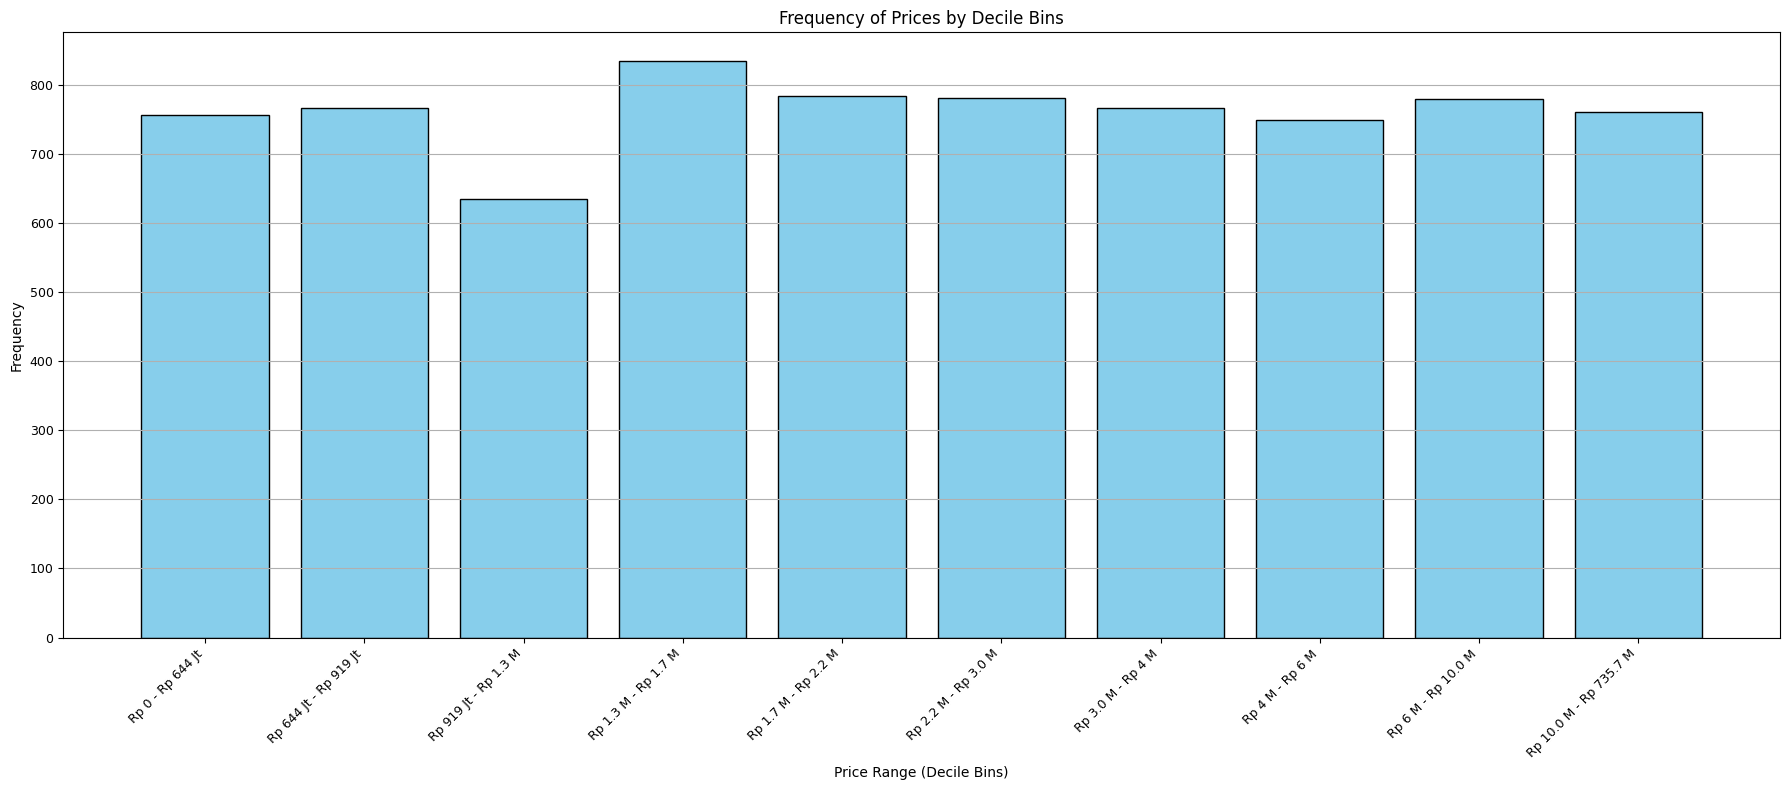

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

plt.figure(figsize=(18, 8)) # Increased figure size for better readability and to reduce x-axis label overlap

# Define bin edges based on deciles
bins = [df['price_numeric'].quantile(i/100) for i in range(0, 101, 10)]
# Ensure the first bin starts at 0 and the last bin covers the max price accurately
bins[0] = 0.0 # Start from 0
bins[-1] = df['price_numeric'].max() + (df['price_numeric'].max() * 0.001) # Add a small buffer to ensure max value is included

# Create a categorical series based on the bins
price_bins = pd.cut(df['price_numeric'], bins=bins, include_lowest=True, right=False)

# Calculate frequency for each bin
frequency_table = price_bins.value_counts().sort_index().reset_index()
frequency_table.columns = ['Price Range (Decile Bins)', 'Frequency']

# Customizing labels for the frequency table for better readability
def format_bin_label(interval):
    lower = interval.left
    upper = interval.right

    # Helper to format numbers for display
    def format_price(value):
        if value == 0:
            return "Rp 0"
        elif value >= 1_000_000_000:
            val_m = value / 1_000_000_000
            if val_m == int(val_m):
                return f"Rp {int(val_m)} M"
            else:
                return f"Rp {val_m:.1f} M"
        elif value >= 1_000_000:
            val_jt = value / 1_000_000
            if val_jt == int(val_jt):
                return f"Rp {int(val_jt)} Jt"
            else:
                return f"Rp {val_jt:.1f} Jt"
        else:
            return f"Rp {value:,.0f}"

    return f"{format_price(lower)} - {format_price(upper)}"

frequency_table['Price Range (Decile Bins)'] = frequency_table['Price Range (Decile Bins)'].apply(format_bin_label)

print("\nFrequency Table (based on Decile Bins):")
print(frequency_table.to_string(index=False))

# --- Now, generate the bar plot based on the frequency table ---

# Use the frequency_table to plot directly as a bar chart
plt.bar(frequency_table['Price Range (Decile Bins)'], frequency_table['Frequency'], color='skyblue', edgecolor='black')
plt.title('Frequency of Prices by Decile Bins')
plt.xlabel('Price Range (Decile Bins)')
plt.ylabel('Frequency')
plt.grid(axis='y') # Grid on y-axis is often sufficient for bar plots

# Customizing x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=9) # Rotate labels for readability
plt.yticks(fontsize=9) # Ensure y-axis labels are also readable
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

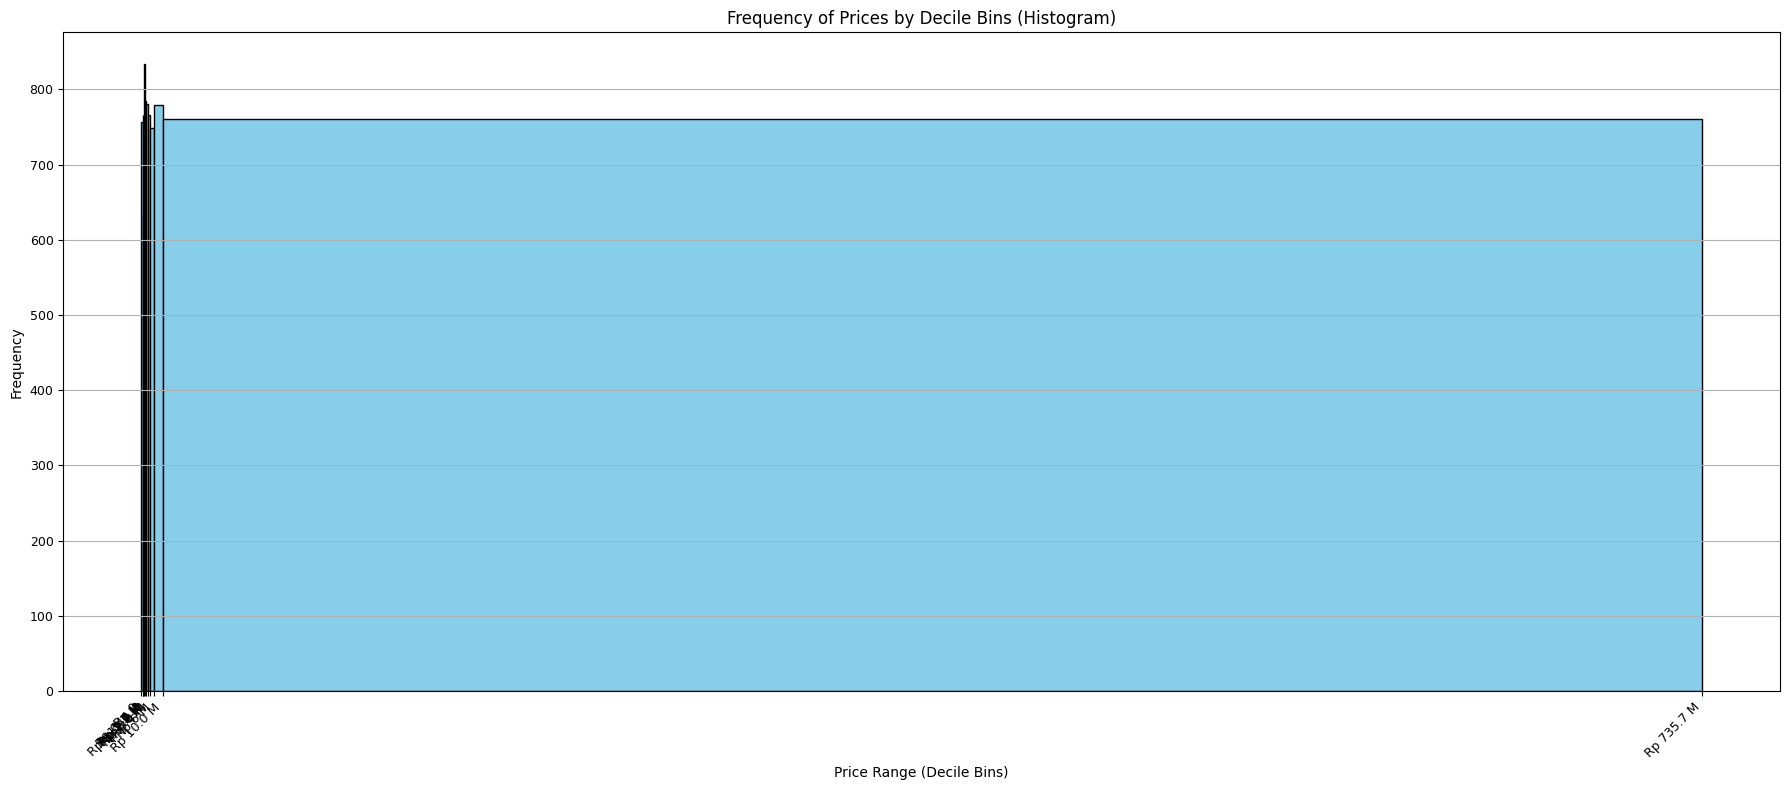

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported if not already


plt.figure(figsize=(18, 8)) # Increased figure size for better readability and to reduce x-axis label overlap

# Define bin edges based on deciles
bins = [df['price_numeric'].quantile(i/100) for i in range(0, 101, 10)]
# Ensure the first bin starts at 0 and the last bin covers the max price accurately
bins[0] = 0.0 # Start from 0
bins[-1] = df['price_numeric'].max() + (df['price_numeric'].max() * 0.001) # Add a small buffer to ensure max value is included

# --- Generate the histogram ---

plt.hist(df['price_numeric'], bins=bins, color='skyblue', edgecolor='black') # density=False for a standard histogram showing counts
plt.title('Frequency of Prices by Decile Bins (Histogram)')
plt.xlabel('Price Range (Decile Bins)')
plt.ylabel('Frequency')
plt.grid(axis='y') # Grid on y-axis is often sufficient for histograms

# Customizing x-axis labels
tick_positions = bins
tick_labels = []

for i, val in enumerate(bins):
    if i == 0:
        tick_labels.append("Rp 0")
    elif val >= 1_000_000_000:
        val_m = val / 1_000_000_000
        if val_m == int(val_m): # Check if it's a whole number of billions
            tick_labels.append(f"Rp {int(val_m)} M")
        else:
            tick_labels.append(f"Rp {val_m:.1f} M")
    elif val >= 1_000_000:
        val_jt = val / 1_000_000
        if val_jt == int(val_jt): # Check if it's a whole number of millions
            tick_labels.append(f"Rp {int(val_jt)} Jt")
        else:
            tick_labels.append(f"Rp {val_jt:.1f} Jt")
    else:
        tick_labels.append(f"Rp {val:,.0f}") # Fallback for values less than 1 million

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right', fontsize=9) # Rotate labels for readability
plt.yticks(fontsize=9) # Ensure y-axis labels are also readable
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
df

,Rumah,Premier,"Rp 2,1 Miliar",Cicilan: 7 Jutaan per bulan,"Rumah 2 Lantai Bagus Sertifikat Hak Milik di Maltra Residence, Bandung","Andir, Bandung",3,2,2.1,137 m²,170 m²,price_numeric
0,Rumah,NaN,"Rp 4,1 Miliar",Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²,4.100000e+09
1,Rumah,NaN,"Rp 3,3 Miliar",Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²,3.300000e+09
2,Rumah,NaN,Rp 580 Juta,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²,5.800000e+08
3,Rumah,NaN,"Rp 1,3 Miliar",Cicilan: 4 Jutaan per bulan,Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²,1.300000e+09
4,Rumah,NaN,"Rp 3,6 Miliar",Cicilan: 13 Jutaan per bulan,"Rumah 2,5 Lantai Strategis SHM di Komplek Kert...","Andir, Bandung",5,3,1,184 m²,234 m²,3.600000e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
7605,Rumah,NaN,Rp 11 Miliar,Cicilan: 40 Jutaan per bulan,"Rumah Lux Terawat di Taman Sakura Raya , Bandung","Babakanciparay, Bandung",4,5,0,600 m²,500 m²,1.100000e+10
7606,Rumah,NaN,"Rp 3,2 Miliar",Cicilan: 11 Jutaan per bulan,Rumah 3 Lantai Bagus Terawat di Sumber Sari,"Babakanciparay, Bandung",4,5,2,200 m²,600 m²,3.200000e+09
7607,Rumah,NaN,"Rp 5,5 Miliar",Cicilan: 20 Jutaan per bulan,Rumah Besar Elegant Asri Nyaman Sumbersari Ban...,"Babakanciparay, Bandung",6,3,3,375 m²,290 m²,5.500000e+09
7608,Rumah,NaN,"Rp 4,89 Miliar",Cicilan: 18 Jutaan per bulan,Rumah strategis nyaman belakang mall sumber sa...,"Babakanciparay, Bandung",5,3,3,375 m²,290 m²,4.890000e+09


In [ ]:
## Memodifikasi nama kolom

# Drop the original price column since 'price_numeric' has been created
df = df.drop(columns=['Rp 2,1 Miliar'])

# Define the new column names in the specified order
new_column_names = [
    'type', 'status', 'installment', 'house_name', 'location',
    'bedroom_count', 'bathroom_count', 'carport_count', 'land_area', 'building_area', 'price_numeric'
]

# Rename the columns
df.columns = new_column_names

# Display the DataFrame with new column names
display(df.head())

,type,status,installment,house_name,location,bedroom_count,bathroom_count,carport_count,land_area,building_area,price_numeric
0,Rumah,NaN,Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²,4.100000e+09
1,Rumah,NaN,Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²,3.300000e+09
2,Rumah,NaN,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²,5.800000e+08
3,Rumah,NaN,Cicilan: 4 Jutaan per bulan,Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²,1.300000e+09
4,Rumah,NaN,Cicilan: 13 Jutaan per bulan,"Rumah 2,5 Lantai Strategis SHM di Komplek Kert...","Andir, Bandung",5,3,1,184 m²,234 m²,3.600000e+09


In [ ]:
df

,type,status,installment,house_name,location,bedroom_count,bathroom_count,carport_count,land_area,building_area,price_numeric
0,Rumah,NaN,Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²,4.100000e+09
1,Rumah,NaN,Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²,3.300000e+09
2,Rumah,NaN,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²,5.800000e+08
3,Rumah,NaN,Cicilan: 4 Jutaan per bulan,Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²,1.300000e+09
4,Rumah,NaN,Cicilan: 13 Jutaan per bulan,"Rumah 2,5 Lantai Strategis SHM di Komplek Kert...","Andir, Bandung",5,3,1,184 m²,234 m²,3.600000e+09
...,...,...,...,...,...,...,...,...,...,...,...
7605,Rumah,NaN,Cicilan: 40 Jutaan per bulan,"Rumah Lux Terawat di Taman Sakura Raya , Bandung","Babakanciparay, Bandung",4,5,0,600 m²,500 m²,1.100000e+10
7606,Rumah,NaN,Cicilan: 11 Jutaan per bulan,Rumah 3 Lantai Bagus Terawat di Sumber Sari,"Babakanciparay, Bandung",4,5,2,200 m²,600 m²,3.200000e+09
7607,Rumah,NaN,Cicilan: 20 Jutaan per bulan,Rumah Besar Elegant Asri Nyaman Sumbersari Ban...,"Babakanciparay, Bandung",6,3,3,375 m²,290 m²,5.500000e+09
7608,Rumah,NaN,Cicilan: 18 Jutaan per bulan,Rumah strategis nyaman belakang mall sumber sa...,"Babakanciparay, Bandung",5,3,3,375 m²,290 m²,4.890000e+09


## Day 4

In [ ]:
X = df.drop(columns=["price_numeric"])
y = df["price_numeric"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# karena ada data kategorik, kita pilih data numerik murni saja
numeric_features = [
    "bedroom_count",
    "bathroom_count",
    "carport_count"
]

X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_num, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test_num)


In [ ]:
y_pred


array([4.48834242e+09, 3.40957032e+09, 4.15191616e+09, ...,
       3.42906878e+09, 6.99081340e+09, 4.15191616e+09])

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae


3827764537.768167

In [ ]:
import numpy as np

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mape


np.float64(219.43895992704307)

## DAY 6

## Gabungkan Data dan Hitung Kuartil

In [ ]:
y_pred_series = pd.Series(y_pred, index=y_test.index)
price_comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_series})

Q1 = price_comparison_df['Actual'].quantile(0.25)
Q3 = price_comparison_df['Actual'].quantile(0.75)

print(f"DataFrame kombinasi y_test dan y_pred:")
display(price_comparison_df.head())
print(f"\nKuartil Pertama (Q1) dari harga aktual: Rp {Q1:,.0f}")
print(f"Kuartil Ketiga (Q3) dari harga aktual: Rp {Q3:,.0f}")
len(y_pred_series)

DataFrame kombinasi y_test dan y_pred:


,Actual,Predicted
2644,4.400000e+09,4.488342e+09
2227,4.600000e+09,3.409570e+09
5447,5.700000e+08,4.151916e+09
132,3.600000e+09,5.567115e+09
5540,1.200000e+09,3.073144e+09



Kuartil Pertama (Q1) dari harga aktual: Rp 1,200,000,000
Kuartil Ketiga (Q3) dari harga aktual: Rp 4,500,000,000


1522

In [ ]:
def categorize_price_segment(price):
    if price < Q1:
        return 'Harga Rendah'
    elif Q1 <= price <= Q3:
        return 'Harga Menengah'
    else:
        return 'Harga Tinggi'

price_comparison_df['Segment'] = price_comparison_df['Actual'].apply(categorize_price_segment)

print("DataFrame dengan segmen harga:")
display(price_comparison_df.head())

DataFrame dengan segmen harga:


,Actual,Predicted,Segment
2644,4.400000e+09,4.488342e+09,Harga Menengah
2227,4.600000e+09,3.409570e+09,Harga Tinggi
5447,5.700000e+08,4.151916e+09,Harga Rendah
132,3.600000e+09,5.567115e+09,Harga Menengah
5540,1.200000e+09,3.073144e+09,Harga Menengah


In [ ]:
performance_metrics = []

for segment in price_comparison_df['Segment'].unique():
    segment_df = price_comparison_df[price_comparison_df['Segment'] == segment]

    num_data_points = len(segment_df)

    # Calculate MAE for the segment
    mae_segment = np.mean(np.abs(segment_df['Actual'] - segment_df['Predicted']))

    # Calculate MAPE for the segment, handling division by zero for actual prices if any (though unlikely for price data)
    mape_segment = np.mean(np.abs((segment_df['Actual'] - segment_df['Predicted']) / segment_df['Actual'])) * 100

    performance_metrics.append({
        'Segment': segment,
        'Jumlah Data': num_data_points,
        'MAE': mae_segment,
        'MAPE (%)': mape_segment
    })

performance_df = pd.DataFrame(performance_metrics)
print("Metrik kinerja model berdasarkan segmen harga:")
display(performance_df)

Metrik kinerja model berdasarkan segmen harga:


,Segment,Jumlah Data,MAE,MAPE (%)
0,Harga Menengah,774,2.398652e+09,121.212169
1,Harga Tinggi,369,7.590384e+09,44.617121
2,Harga Rendah,379,3.082980e+09,590.248445


### Analisis Kinerja Model Berdasarkan Segmen Harga

Berikut adalah tabel yang menunjukkan kinerja model (MAE dan MAPE) untuk setiap segmen harga:

| Segmen Harga   | Jumlah Data | MAE (Rupiah)         | MAPE (%)       |
|:---------------|:------------|:---------------------|:---------------|
| Harga Menengah | 774         | Rp 2,398,651,957     | 121.21         |
| Harga Tinggi   | 369         | Rp 7,590,383,545     | 44.62          |
| Harga Rendah   | 379         | Rp 3,082,980,168     | 590.25         |

## Summary:

### Data Analysis Key Findings

*   The actual prices were segmented using quartiles: the first quartile (Q1) was Rp 1,200,000,000, and the third quartile (Q3) was Rp 4,500,000,000.
*   The model's performance varies significantly across price segments:
    *   **Harga Rendah** (below Rp 1,200,000,000, 379 data points): Showed the highest Mean Absolute Percentage Error (MAPE) at 590.25% and a Mean Absolute Error (MAE) of Rp 3,082,980,168.
    *   **Harga Menengah** (between Rp 1,200,000,000 and Rp 4,500,000,000, 774 data points): Had an MAE of Rp 2,398,651,957 and a MAPE of 121.21%. This segment had the most data points.
    *   **Harga Tinggi** (above Rp 4,500,000,000, 369 data points): Recorded the highest MAE of Rp 7,590,383,545 but the lowest MAPE at 44.62%.

### Insights or Next Steps

*   The extremely high MAPE for the 'Harga Rendah' segment suggests that while the absolute errors might not be the largest, they represent a very large percentage of the actual low prices. This indicates poor relative predictive accuracy for inexpensive properties.
*   Further investigation is needed into the 'Harga Rendah' segment to understand why the MAPE is so high, potentially by analyzing the distribution of errors or checking for data quality issues in this range.


## DAY 7

In [ ]:
y_pred_series_day7 = pd.concat([price_comparison_df, X_test_num], axis=1)
y_pred_series_day7

,Actual,Predicted,Segment,bedroom_count,bathroom_count,carport_count
2644,4.400000e+09,4.488342e+09,Harga Menengah,4,3,1
2227,4.600000e+09,3.409570e+09,Harga Tinggi,4,3,0
5447,5.700000e+08,4.151916e+09,Harga Rendah,3,2,1
132,3.600000e+09,5.567115e+09,Harga Menengah,4,3,2
5540,1.200000e+09,3.073144e+09,Harga Menengah,3,2,0
...,...,...,...,...,...,...
6424,3.900000e+09,4.449345e+09,Harga Menengah,4,5,1
1835,8.500000e+09,8.058588e+09,Harga Tinggi,11,3,2
506,6.000000e+08,3.429069e+09,Harga Rendah,4,2,0
3592,7.000000e+09,6.990813e+09,Harga Tinggi,8,3,2


In [ ]:
y_pred_series_day7 = pd.concat([price_comparison_df, X_test_num], axis=1)
y_pred_series_day7

,Actual,Predicted,Segment,bedroom_count,bathroom_count,carport_count
2644,4.400000e+09,4.488342e+09,Harga Menengah,4,3,1
2227,4.600000e+09,3.409570e+09,Harga Tinggi,4,3,0
5447,5.700000e+08,4.151916e+09,Harga Rendah,3,2,1
132,3.600000e+09,5.567115e+09,Harga Menengah,4,3,2
5540,1.200000e+09,3.073144e+09,Harga Menengah,3,2,0
...,...,...,...,...,...,...
6424,3.900000e+09,4.449345e+09,Harga Menengah,4,5,1
1835,8.500000e+09,8.058588e+09,Harga Tinggi,11,3,2
506,6.000000e+08,3.429069e+09,Harga Rendah,4,2,0
3592,7.000000e+09,6.990813e+09,Harga Tinggi,8,3,2


## DAY 8

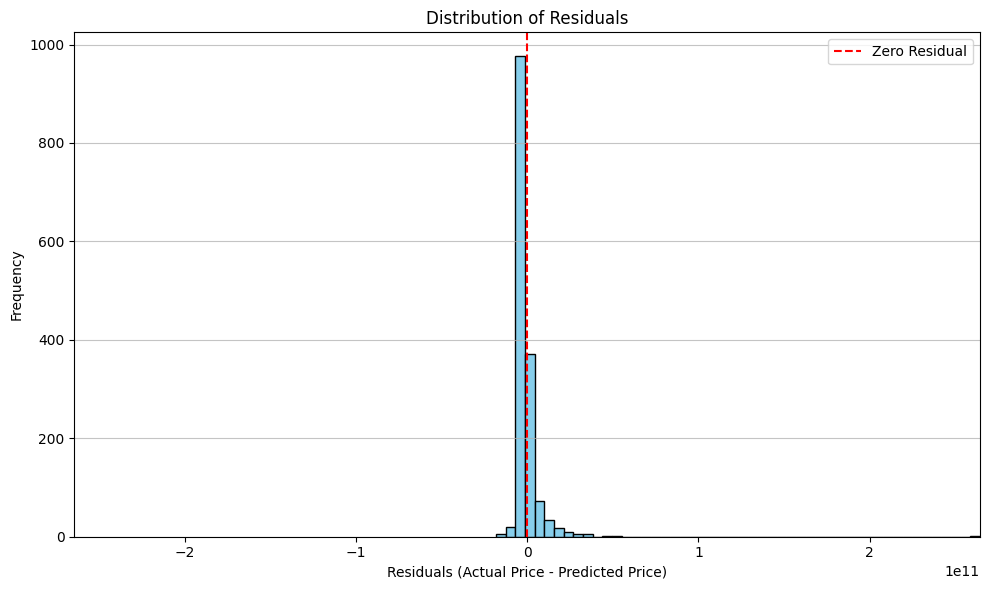


Descriptive Statistics of Residuals:


,0
count,1.522000e+03
mean,-3.847699e+08
std,9.055104e+09
min,-1.821241e+10
25%,-3.207452e+09
50%,-2.120644e+09
75%,-4.257612e+08
max,2.644424e+11


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = price_comparison_df['Actual'] - price_comparison_df['Predicted']

# Determine the maximum absolute residual to set symmetrical x-axis limits
max_abs_residual = np.max(np.abs(residuals))

# Plotting the histogram of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual Price - Predicted Price)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero Residual') # Add a vertical line at 0
plt.xlim(-max_abs_residual, max_abs_residual) # Set x-axis limits symmetrically around 0
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Optionally, print some descriptive statistics of the residuals
print('\nDescriptive Statistics of Residuals:')
display(residuals.describe())

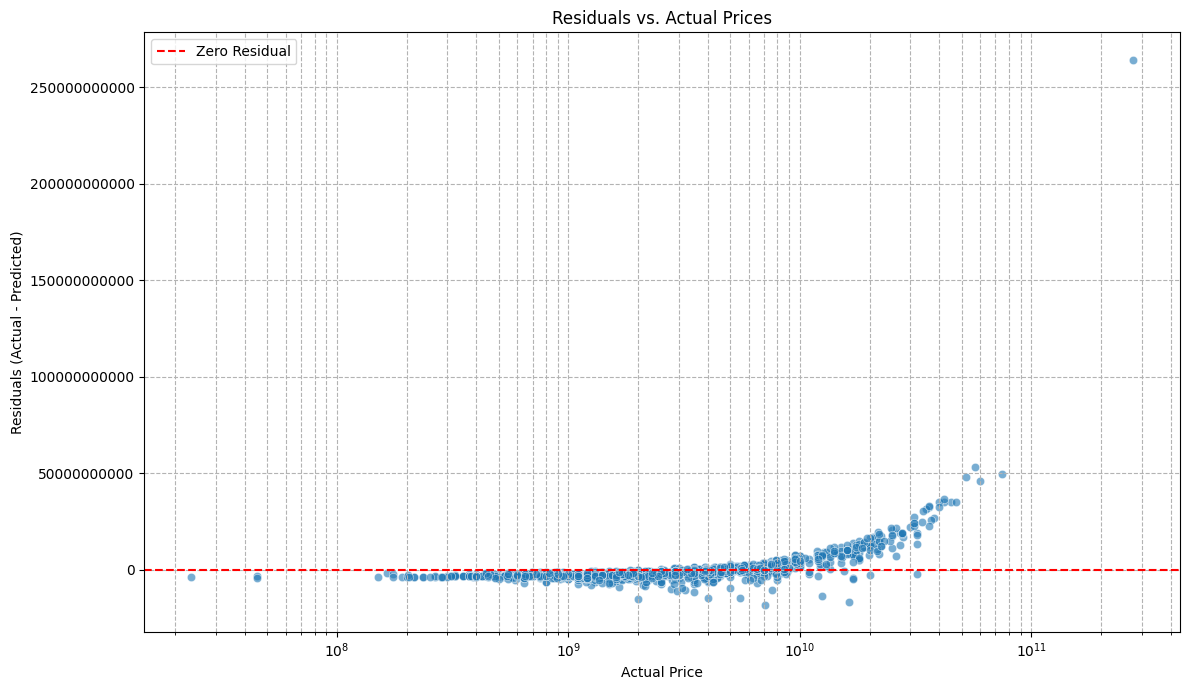

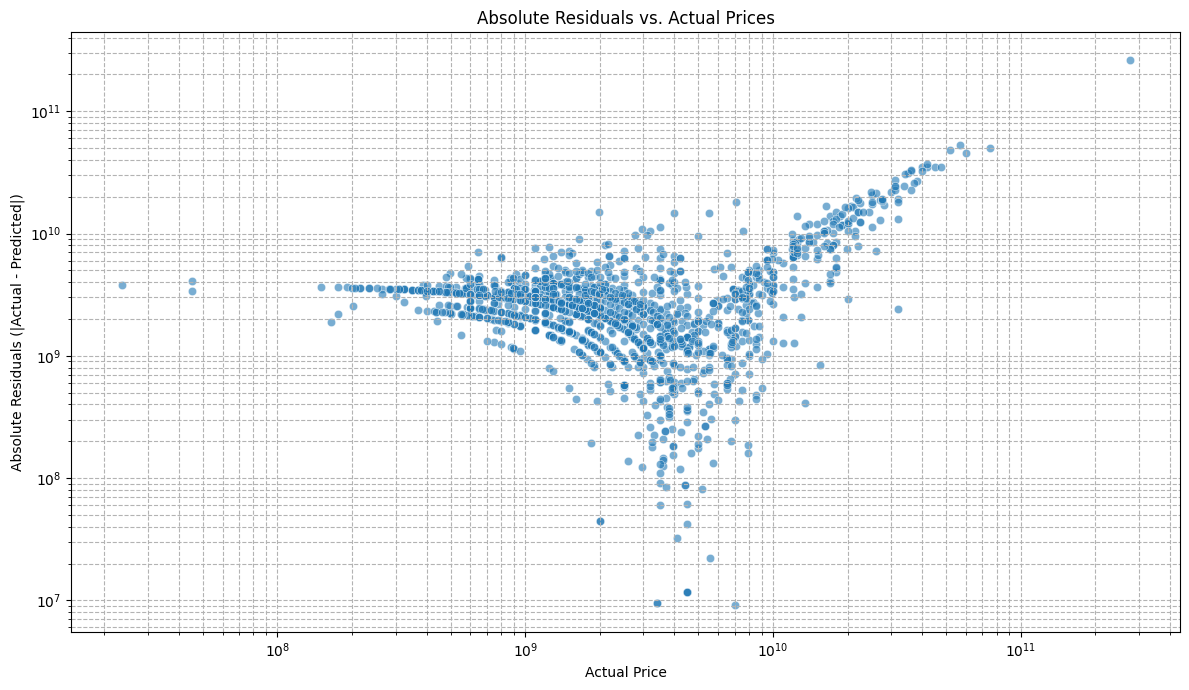

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure residuals are calculated
residuals = price_comparison_df['Actual'] - price_comparison_df['Predicted']

plt.figure(figsize=(12, 7))
sns.scatterplot(x=price_comparison_df['Actual'], y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')
plt.title('Residuals vs. Actual Prices')
plt.xlabel('Actual Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.xscale('log') # Use log scale for actual price to better visualize spread, as prices can vary widely
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis for residuals
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(x=price_comparison_df['Actual'], y=np.abs(residuals), alpha=0.6)
plt.title('Absolute Residuals vs. Actual Prices')
plt.xlabel('Actual Price')
plt.ylabel('Absolute Residuals (|Actual - Predicted|)')
plt.xscale('log')
plt.yscale('log') # Use log scale for absolute residuals as well to see spread more clearly
# Removed: plt.ticklabel_format(style='plain', axis='y') # This line caused the error
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()


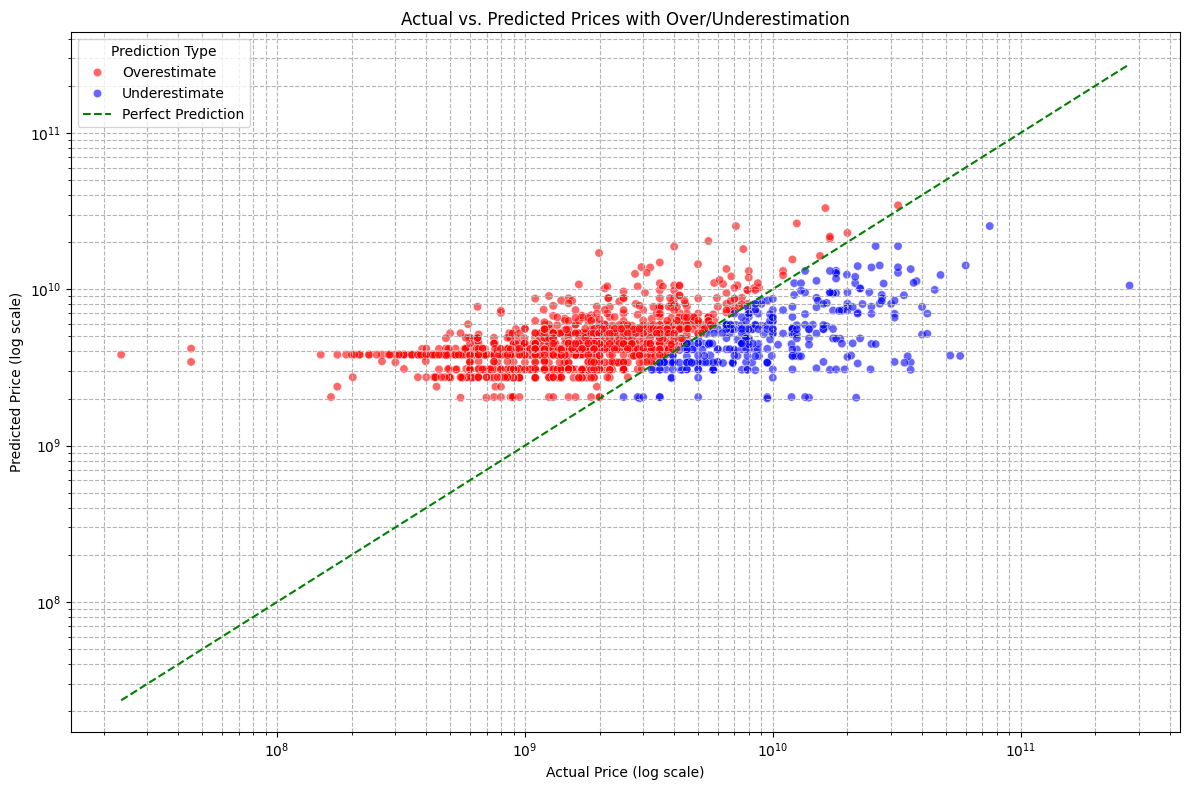

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Kategorikan apakah model overestimate atau underestimate
price_comparison_df['Prediction_Type'] = np.where(
    price_comparison_df['Predicted'] > price_comparison_df['Actual'],
    'Overestimate',
    'Underestimate'
)

# Buat scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=price_comparison_df,
    x='Actual',
    y='Predicted',
    hue='Prediction_Type', # Warna berdasarkan jenis prediksi
    palette={'Overestimate': 'red', 'Underestimate': 'blue'},
    alpha=0.6
)

# Tambahkan garis y=x (prediksi sempurna)
plt.plot(
    [price_comparison_df['Actual'].min(), price_comparison_df['Actual'].max()],
    [price_comparison_df['Actual'].min(), price_comparison_df['Actual'].max()],
    color='green', linestyle='--', label='Perfect Prediction'
)

plt.title('Actual vs. Predicted Prices with Over/Underestimation')
plt.xlabel('Actual Price (log scale)')
plt.ylabel('Predicted Price (log scale)')
plt.xscale('log') # Gunakan skala logaritmik untuk sumbu x
plt.yscale('log') # Gunakan skala logaritmik untuk sumbu y
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Prediction Type')
plt.tight_layout()
plt.show()

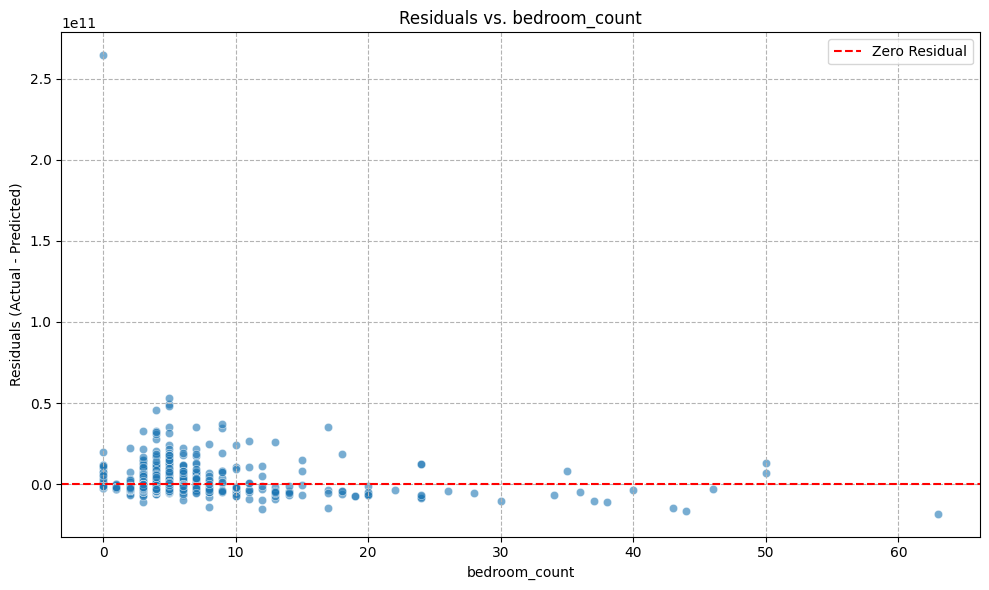

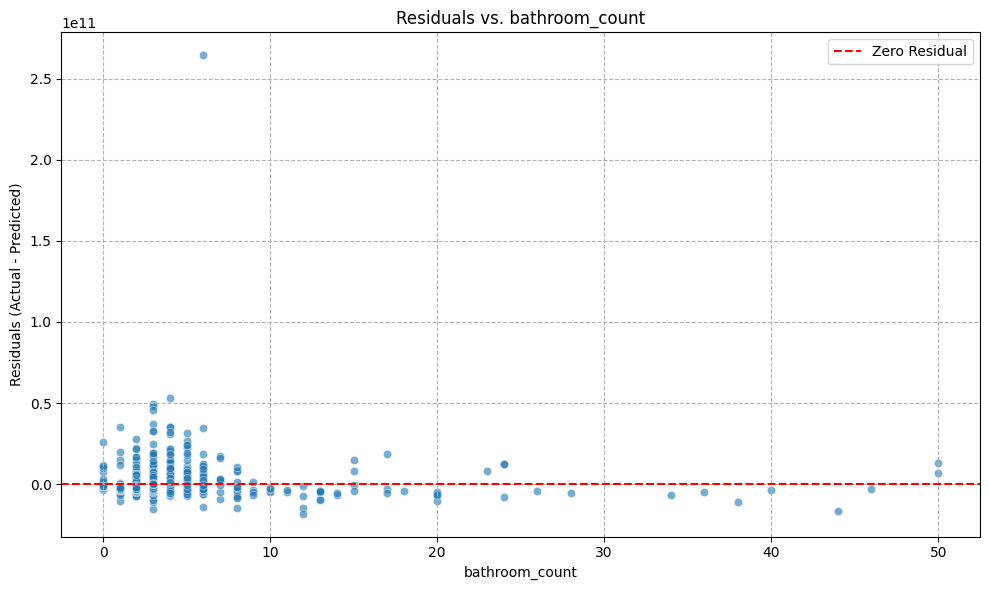

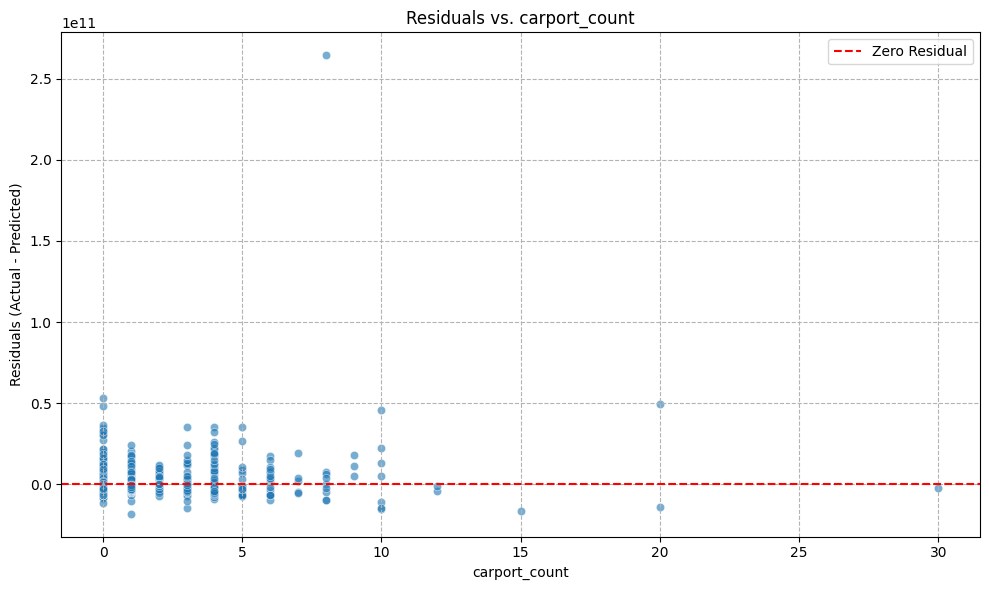

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals (if not already calculated)
residuals = price_comparison_df['Actual'] - price_comparison_df['Predicted']

# Combine residuals with X_test_num for plotting
# We already have `y_pred_series_day7` from previous steps which contains this combination
# If not, it would be created as: plot_df = pd.concat([X_test_num, pd.Series(residuals, index=X_test_num.index, name='Residuals')], axis=1)
plot_df = y_pred_series_day7.copy() # Use the DataFrame that already combines these
plot_df['Residuals'] = residuals # Add residuals column

features_to_plot = ['bedroom_count', 'bathroom_count', 'carport_count']

for feature in features_to_plot:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=feature, y='Residuals', data=plot_df, alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')
    plt.title(f'Residuals vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.legend()
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.tight_layout()
    plt.show()

### Analisis Residual Berdasarkan Fitur

Setelah melihat plot di atas untuk `bedroom_count`, `bathroom_count`, dan `carport_count`, mari kita jawab pertanyaan Anda:

1.  **Apakah residual berubah seiring nilai fitur meningkat?**
    *   Perhatikan apakah sebaran titik-titik (residual) melebar atau menyempit, atau apakah ada kecenderungan titik-titik untuk berada di atas atau di bawah garis nol (bias) seiring peningkatan nilai fitur. Misalnya, apakah model cenderung overestimate untuk rumah dengan sedikit kamar tidur dan underestimate untuk rumah dengan banyak kamar tidur?

2.  **Apakah ada nilai fitur tertentu yang sering memicu error besar?**
    *   Identifikasi jika ada 'kelompok' titik-titik residual yang jauh dari garis nol pada nilai fitur tertentu. Ini bisa menunjukkan bahwa model kesulitan memprediksi untuk properti dengan karakteristik tersebut (misalnya, rumah dengan jumlah kamar mandi yang sangat sedikit atau sangat banyak).

3.  **Apakah pola ini masuk akal secara logika properti?**
    *   Misalnya, jika model sering underestimate rumah dengan jumlah kamar tidur sangat banyak, apakah ini karena data rumah dengan banyak kamar tidur jarang dan model kurang belajar dari sana? Atau apakah rumah dengan `carport_count` 0 (tidak ada garasi) memiliki residual yang aneh karena model mungkin tidak menangani kasus ekstrem ini dengan baik?

Silakan amati setiap plot dan catat temuan Anda untuk setiap fitur. Dengan visualisasi ini, Anda bisa melihat hubungan antara karakteristik properti dan kinerja model.

### Penggunaan Skala Logaritmik

Dalam grafik-grafik yang kita buat, skala logaritmik digunakan pada:

1.  **Sumbu X (Actual Price)** pada grafik 'Residuals vs. Actual Prices' dan 'Absolute Residuals vs. Actual Prices'.
2.  **Kedua Sumbu (Actual Price dan Predicted Price)** pada grafik 'Actual vs. Predicted Prices with Over/Underestimation'.
3.  **Sumbu Y (Absolute Residuals)** pada grafik 'Absolute Residuals vs. Actual Prices'.

#### Mengapa Menggunakan Skala Logaritmik?

Penggunaan skala logaritmik sangat penting ketika Anda berhadapan dengan data yang memiliki **rentang nilai yang sangat lebar (spanning multiple orders of magnitude)**. Dalam kasus data harga properti kita, harga bisa bervariasi dari puluhan juta hingga puluhan atau bahkan ratusan miliar Rupiah. Jika kita menggunakan skala linear biasa (misalnya 0, 10 M, 20 M, dst.):

1.  **Kompresi Data:** Nilai-nilai yang lebih kecil (misalnya, semua harga di bawah 1 Miliar) akan terlihat sangat rapat dan terkompresi di dekat titik asal sumbu, sehingga detail dan pola pada rentang harga rendah tersebut menjadi tidak terlihat.
2.  **Rentang Tidak Proporsional:** Perubahan dari 10 Juta ke 100 Juta akan tampak sama dengan perubahan dari 10 Miliar ke 100 Miliar pada skala linear, padahal secara persentase atau relatif, perubahan tersebut sangat berbeda.

Dengan **skala logaritmik**, kita bisa:

*   **Memperluas Rentang Bawah:** Nilai-nilai yang lebih kecil 'direntangkan' sehingga kita bisa melihat perbedaan dan pola di antara mereka dengan lebih jelas.
*   **Mengkompres Rentang Atas:** Nilai-nilai yang sangat besar 'dikompresi' agar tidak mendominasi seluruh grafik, namun tetap terlihat dalam konteks.
*   **Melihat Perubahan Relatif/Persentase:** Skala logaritmik secara implisit menampilkan hubungan multiplikatif atau perubahan persentase dengan lebih baik. Setiap interval pada sumbu logaritmik mewakili kelipatan yang sama (misalnya, dari 100 ke 1.000 ke 10.000, dst.).

Dalam analisis residual kita, menggunakan skala logaritmik pada sumbu harga aktual dan prediksi membantu kita untuk:

*   Melihat bagaimana residual atau error absolut berperilaku di seluruh spektrum harga, dari yang terendah hingga tertinggi, tanpa mengorbankan detail di salah satu ujung. Misalnya, kita bisa lebih jelas melihat pola heteroscedasticity (di mana error membesar seiring harga) dan bias overestimate/underestimate di rentang harga tertentu.

Singkatnya, skala logaritmik digunakan untuk membuat visualisasi data yang memiliki rentang luas menjadi lebih informatif dan mudah diinterpretasi.

### Analisis Pola Overestimate dan Underestimate

Dari grafik di atas, kita dapat menganalisis:

*   **Overestimate (Titik Merah):** Terletak di atas garis "Perfect Prediction" (garis putus-putus hijau). Semakin jauh titik merah dari garis ini, semakin besar overestimasi model.
*   **Underestimate (Titik Biru):** Terletak di bawah garis "Perfect Prediction". Semakin jauh titik biru dari garis ini, semakin besar underestimasi model.

Dengan melihat sebaran titik-titik merah dan biru di berbagai rentang harga (sumbu x dan y), Anda dapat mengidentifikasi:

1.  **Rentang Harga Mana Model Sering Overestimate/Underestimate?**
    *   Perhatikan kepadatan titik merah dan biru di bagian kiri bawah (harga rendah) vs. kanan atas (harga tinggi). Apakah ada satu warna yang mendominasi di rentang tertentu?

2.  **Apakah Kesalahan Ini Acak atau Konsisten?**
    *   Jika titik-titik (merah dan biru) tersebar secara merata di sekitar garis prediksi sempurna tanpa pola yang jelas di seluruh rentang harga, maka kesalahannya bisa dikatakan acak. Namun, jika ada kecenderungan kuat (misalnya, sebagian besar titik biru berada di area harga tinggi, atau sebagian besar titik merah berada di area harga rendah), maka kesalahan tersebut konsisten pada rentang tertentu.

Biasanya, pada model regresi yang sederhana, kita sering melihat pola seperti:
*   **Overestimasi di harga rendah:** Model mungkin memprediksi harga properti rendah menjadi lebih tinggi dari seharusnya.
*   **Underestimasi di harga tinggi:** Model mungkin memprediksi harga properti tinggi menjadi lebih rendah dari seharusnya.

Analisis visual ini akan membantu mengkonfirmasi atau membantah pola tersebut pada model Anda.

## DAY 9

In [ ]:
def clean_area_to_numeric(area_str):
    if isinstance(area_str, str):
        # Extract numbers using regex, handling potential commas as decimal separators if needed
        # Here we assume 'm²' is always present and the number is before it
        try:
            return float(area_str.replace(' m²', '').replace(',', '.'))
        except ValueError:
            return None # Handle cases where conversion fails
    return None # Handle non-string values (e.g., NaN)

# Apply the cleaning function to 'land_area' and create 'land_area_sqm'
df['land_area_sqm'] = df['land_area'].apply(clean_area_to_numeric)

# Apply the cleaning function to 'building_area' and create 'building_area_sqm'
df['building_area_sqm'] = df['building_area'].apply(clean_area_to_numeric)

print("DataFrame dengan kolom area numerik baru:")
display(df.head())

DataFrame dengan kolom area numerik baru:


,type,status,installment,house_name,location,bedroom_count,bathroom_count,carport_count,land_area,building_area,price_numeric,land_area_sqm,building_area_sqm
0,Rumah,NaN,Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²,4.100000e+09,202.0,300.0
1,Rumah,NaN,Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²,3.300000e+09,350.0,258.0
2,Rumah,NaN,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²,5.800000e+08,30.0,80.0
3,Rumah,NaN,Cicilan: 4 Jutaan per bulan,Jual Rumah Murah Bisa Dijadikan Kos”an Di Jala...,"Andir, Bandung",11,3,0,176 m²,176 m²,1.300000e+09,176.0,176.0
4,Rumah,NaN,Cicilan: 13 Jutaan per bulan,"Rumah 2,5 Lantai Strategis SHM di Komplek Kert...","Andir, Bandung",5,3,1,184 m²,234 m²,3.600000e+09,184.0,234.0


In [ ]:
# Menghapus baris dengan nilai 0 atau NaN di 'land_area_sqm' atau 'building_area_sqm'
df_cleaned = df.replace(0, np.nan).dropna(subset=['land_area_sqm', 'building_area_sqm'])
df_cleaned = df_cleaned.replace(np.nan, 0)

# Redefinisikan y dan X dari DataFrame yang sudah dibersihkan
y = df_cleaned["price_numeric"]
X = df_cleaned[
    [
        "bedroom_count",
        "bathroom_count",
        "carport_count",
        "land_area_sqm",
        "building_area_sqm"
    ]
]

print(f"Jumlah baris setelah pembersihan: {len(df_cleaned)}")
print("X setelah pembersihan:")
display(X.head())

Jumlah baris setelah pembersihan: 7608
X setelah pembersihan:


,bedroom_count,bathroom_count,carport_count,land_area_sqm,building_area_sqm
0,3.0,2.0,3.0,202.0,300.0
1,5.0,2.0,1.0,350.0,258.0
2,2.0,2.0,1.0,30.0,80.0
3,11.0,3.0,0.0,176.0,176.0
4,5.0,3.0,1.0,184.0,234.0


In [ ]:
y

,price_numeric
0,4.100000e+09
1,3.300000e+09
2,5.800000e+08
3,1.300000e+09
4,3.600000e+09
...,...
7605,1.100000e+10
7606,3.200000e+09
7607,5.500000e+09
7608,4.890000e+09


In [ ]:
X

,bedroom_count,bathroom_count,carport_count,land_area_sqm,building_area_sqm
0,3.0,2.0,3.0,202.0,300.0
1,5.0,2.0,1.0,350.0,258.0
2,2.0,2.0,1.0,30.0,80.0
3,11.0,3.0,0.0,176.0,176.0
4,5.0,3.0,1.0,184.0,234.0
...,...,...,...,...,...
7605,4.0,5.0,0.0,600.0,500.0
7606,4.0,5.0,2.0,200.0,600.0
7607,6.0,3.0,3.0,375.0,290.0
7608,5.0,3.0,3.0,375.0,290.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mae

3755612733.2745194

In [ ]:
mape

1.1369214768309233

In [ ]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mape

np.float64(113.69214768309233)

In [ ]:
# Define old model metrics from Day 4-8 for comparison
old_mae = 3827764537.768167
old_mape = 219.43895992704307

# Old segment-wise performance (from notebook output of cell 8081d5fe)
old_performance_data = [
    {'Segment': 'Harga Menengah', 'Jumlah Data': 774, 'MAE': 2398651957.0, 'MAPE (%)': 121.21},
    {'Segment': 'Harga Tinggi', 'Jumlah Data': 369, 'MAE': 7590383545.0, 'MAPE (%)': 44.62},
    {'Segment': 'Harga Rendah', 'Jumlah Data': 379, 'MAE': 3082980168.0, 'MAPE (%)': 590.25}
]
old_performance_df = pd.DataFrame(old_performance_data)


# --- Re-perform segment analysis for the NEW model (Day 9) ---

# Combine actual and predicted prices for the new model
# y_test and y_pred are already updated from the latest model training
new_y_pred_series = pd.Series(y_pred, index=y_test.index)
new_price_comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': new_y_pred_series})

# Calculate Q1 and Q3 for the new y_test
new_Q1 = new_price_comparison_df['Actual'].quantile(0.25)
new_Q3 = new_price_comparison_df['Actual'].quantile(0.75)

# Categorize prices into segments for the new model
def new_categorize_price_segment(price):
    if price < new_Q1:
        return 'Harga Rendah'
    elif new_Q1 <= price <= new_Q3:
        return 'Harga Menengah'
    else:
        return 'Harga Tinggi'

new_price_comparison_df['Segment'] = new_price_comparison_df['Actual'].apply(new_categorize_price_segment)

# Calculate performance metrics for each segment for the new model
new_performance_metrics = []
for segment in new_price_comparison_df['Segment'].unique():
    segment_df = new_price_comparison_df[new_price_comparison_df['Segment'] == segment]

    num_data_points = len(segment_df)
    mae_segment = np.mean(np.abs(segment_df['Actual'] - segment_df['Predicted']))
    mape_segment = np.mean(np.abs((segment_df['Actual'] - segment_df['Predicted']) / segment_df['Actual'])) * 100

    new_performance_metrics.append({
        'Segment': segment,
        'Jumlah Data': num_data_points,
        'MAE': mae_segment,
        'MAPE (%)': mape_segment
    })

new_performance_df = pd.DataFrame(new_performance_metrics)

# --- Compare overall metrics ---
current_mae = mae # from the latest run
current_mape = mape # from the latest run

mae_comparison = {
    "Old MAE": old_mae,
    "New MAE": current_mae,
    "Change": current_mae - old_mae,
    "Percentage Change": ((current_mae - old_mae) / old_mae) * 100
}

mape_comparison = {
    "Old MAPE": old_mape,
    "New MAPE": current_mape,
    "Change": current_mape - old_mape,
    "Percentage Change": ((current_mape - old_mape) / old_mape) * 100
}

print("### Perbandingan Kinerja Model Keseluruhan\n")
print("| Metrik | Model Lama | Model Baru | Perubahan (Absolut) | Perubahan (%) |")
print("|:-------|:-----------|:-----------|:--------------------|:--------------|")
print(f"| MAE    | Rp {mae_comparison['Old MAE']:,.0f} | Rp {mae_comparison['New MAE']:,.0f} | Rp {mae_comparison['Change']:,.0f} | {mae_comparison['Percentage Change']:.2f}% |")
print(f"| MAPE   | {mape_comparison['Old MAPE']:.2f}% | {mape_comparison['New MAPE']:.2f}% | {mape_comparison['Change']:.2f}% | {mape_comparison['Percentage Change']:.2f}% |\n")


print("### Perbandingan Kinerja Model Berdasarkan Segmen Harga\n")

# Merge old and new performance data for comparison
comparison_table = pd.merge(
    old_performance_df.rename(columns={'MAE': 'MAE_Old', 'MAPE (%)': 'MAPE_Old', 'Jumlah Data': 'Jumlah_Data_Old'}),
    new_performance_df.rename(columns={'MAE': 'MAE_New', 'MAPE (%)': 'MAPE_New', 'Jumlah Data': 'Jumlah_Data_New'}),
    on='Segment',
    how='outer'
)

comparison_table['MAE_Change'] = comparison_table['MAE_New'] - comparison_table['MAE_Old']
comparison_table['MAPE_Change'] = comparison_table['MAPE_New'] - comparison_table['MAPE_Old']

print("| Segmen Harga   | Jumlah Data Lama | MAE Lama (Rp)         | MAPE Lama (%) | Jumlah Data Baru | MAE Baru (Rp)         | MAPE Baru (%) | Perubahan MAE (Rp)    | Perubahan MAPE (%) |")
print("|:---------------|:-----------------|:----------------------|:--------------|:-----------------|:----------------------|:--------------|:----------------------|:-------------------|")
for index, row in comparison_table.iterrows():
    print(f"| {row['Segment']} | {row['Jumlah_Data_Old']:.0f} | Rp {row['MAE_Old']:,.0f} | {row['MAPE_Old']:.2f} | {row['Jumlah_Data_New']:.0f} | Rp {row['MAE_New']:,.0f} | {row['MAPE_New']:.2f} | Rp {row['MAE_Change']:,.0f} | {row['MAPE_Change']:.2f} |")

print("\n### Jawaban Pertanyaan\n")
print("1.  **Apakah MAE turun dibanding model lama?**")
if mae_comparison['Change'] < 0:
    print(f"    Ya, MAE turun sebesar Rp {-mae_comparison['Change']:,.0f} ({mae_comparison['Percentage Change']:.2f}%).")
else:
    print(f"    Tidak, MAE naik sebesar Rp {mae_comparison['Change']:,.0f} ({mae_comparison['Percentage Change']:.2f}%).")

print("2.  **Apakah MAPE turun?**")
if mape_comparison['Change'] < 0:
    print(f"    Ya, MAPE turun sebesar {-mape_comparison['Change']:.2f} poin persentase ({mape_comparison['Percentage Change']:.2f}%).")
else:
    print(f"    Tidak, MAPE naik sebesar {mape_comparison['Change']:.2f} poin persentase ({mape_comparison['Percentage Change']:.2f}%).")

print("3.  **Apakah perbaikan terjadi di segmen yang bermasalah (low/high)?**")
low_segment_change_mape = comparison_table[comparison_table['Segment'] == 'Harga Rendah']['MAPE_Change'].iloc[0]
high_segment_change_mape = comparison_table[comparison_table['Segment'] == 'Harga Tinggi']['MAPE_Change'].iloc[0]

if low_segment_change_mape < 0:
    print(f"    **Harga Rendah:** Ya, MAPE untuk segmen 'Harga Rendah' menunjukkan perbaikan, turun sebesar {-low_segment_change_mape:.2f}%. Ini adalah perbaikan signifikan untuk segmen yang sebelumnya sangat bermasalah.")
else:
    print(f"    **Harga Rendah:** Tidak, MAPE untuk segmen 'Harga Rendah' memburuk, naik sebesar {low_segment_change_mape:.2f}%.")

if high_segment_change_mape < 0:
    print(f"    **Harga Tinggi:** Ya, MAPE untuk segmen 'Harga Tinggi' juga menunjukkan perbaikan, turun sebesar {-high_segment_change_mape:.2f}%.")
else:
    print(f"    **Harga Tinggi:** Tidak, MAPE untuk segmen 'Harga Tinggi' memburuk, naik sebesar {high_segment_change_mape:.2f}%.")

print("4.  **Apakah ada segmen lain yang memburuk?**")
other_segments_worsened = comparison_table[comparison_table['MAPE_Change'] > 0]

if not other_segments_worsened.empty:
    worsened_segments = other_segments_worsened['Segment'].tolist()
    print(f"    Ya, beberapa segmen lain yang memburuk (MAPE naik) adalah: {', '.join(worsened_segments)}. Anda bisa melihat detail perubahan MAPE di tabel di atas.")
else:
    print("    Tidak ada segmen lain yang menunjukkan kemunduran (MAPE naik).")

### Perbandingan Kinerja Model Keseluruhan

| Metrik | Model Lama | Model Baru | Perubahan (Absolut) | Perubahan (%) |
|:-------|:-----------|:-----------|:--------------------|:--------------|
| MAE    | Rp 3,827,764,538 | Rp 3,755,612,733 | Rp -72,151,804 | -1.88% |
| MAPE   | 219.44% | 113.69% | -105.75% | -48.19% |

### Perbandingan Kinerja Model Berdasarkan Segmen Harga

| Segmen Harga   | Jumlah Data Lama | MAE Lama (Rp)         | MAPE Lama (%) | Jumlah Data Baru | MAE Baru (Rp)         | MAPE Baru (%) | Perubahan MAE (Rp)    | Perubahan MAPE (%) |
|:---------------|:-----------------|:----------------------|:--------------|:-----------------|:----------------------|:--------------|:----------------------|:-------------------|
| Harga Menengah | 774 | Rp 2,398,651,957 | 121.21 | 784 | Rp 1,572,617,612 | 75.54 | Rp -826,034,345 | -45.67 |
| Harga Rendah | 379 | Rp 3,082,980,168 | 590.25 | 358 | Rp 1,562,590,542 | 279.25 | Rp -1,520,389,626 | -311.00 |
| Harga Tinggi | 369 | Rp 7,5

In [ ]:
import pandas as pd

# Get feature names from the X DataFrame.
# Note: X is already from df_cleaned, which has the correct features.
feature_names = X.columns

# Get coefficients from the trained model
coefficients = model.coef_

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficient', ascending=False)

print("Feature Importance (Coefficients) from the new model:")
display(feature_importance_df_sorted)

Feature Importance (Coefficients) from the new model:


,Feature,Coefficient
2,carport_count,6.087928e+08
0,bedroom_count,1.301252e+08
1,bathroom_count,2.586263e+07
3,land_area_sqm,1.002919e+07
4,building_area_sqm,2.447481e+02


/tmp/ipython-input-2044151609.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df_sorted, palette='viridis')


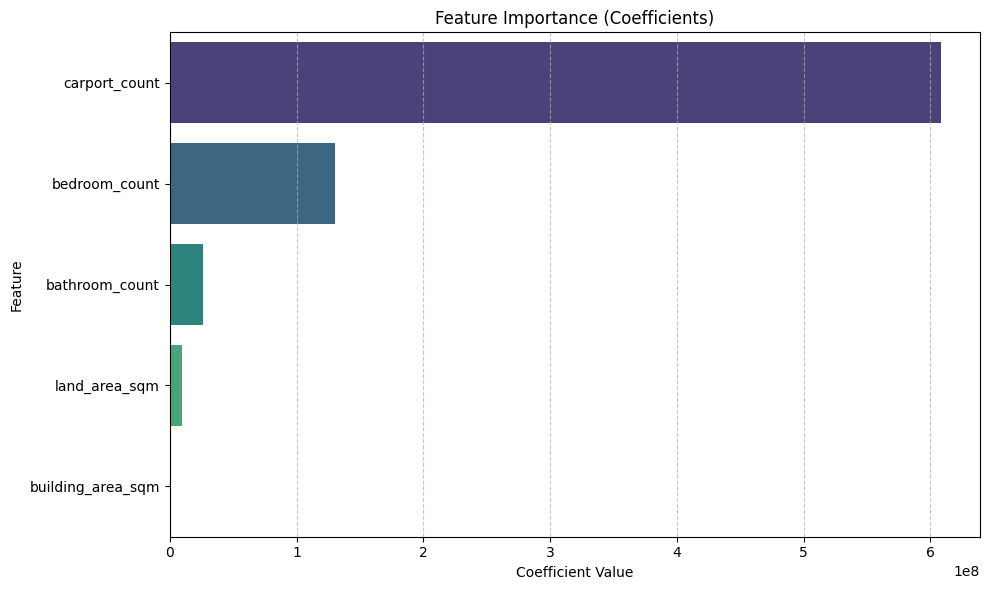

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df_sorted, palette='viridis')
plt.title('Feature Importance (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()